# IMDB情感分析

## 数据准备

train_labels和test_labels都是0和1组成的列表，其中0代表负面（negative），1代表正面（positive）

In [1]:
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np

In [2]:
max_features = 20000    # only consider the top 20k words
maxlen = 380    # only consider the first 380 words of each movie review

In [3]:
(x_train, y_train), (x_val, y_val) = keras.datasets.imdb.load_data(
    num_words=max_features
)
print(len(x_train), "train sequences")
print(len(x_val), "validation sequences")

25000 train sequences
25000 validation sequences


In [4]:
x_train[0][:10]

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]

In [5]:
len(x_train[0])

218

In [6]:
y_train[0:10]

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0], dtype=int64)

In [7]:
word_index = keras.datasets.imdb.get_word_index()

In [8]:
# word_index

In [9]:
index_to_word = {v:k for k, v in word_index.items()}

In [10]:
# index_to_word

In [11]:
# 查看影评
print(' '.join([index_to_word[x] for x in x_train[0]]))

the as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room and it so heart shows to years of every never going and help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but pratfalls to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other tricky in of seen over landed for anyone of and br show's to whether from than out themselves history he name half some br of 'n odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but when from one bit then

## 文章文字等长处理

maxlen=380，所以每一篇文章转成数字都必须为380

In [12]:
x_train_pad = sequence.pad_sequences(x_train, maxlen=maxlen)
x_val_pad = sequence.pad_sequences(x_val, maxlen=maxlen)

## 建立模型

In [13]:
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Embedding, LSTM, SimpleRNN
from tensorflow.keras.layers import SpatialDropout1D, GRU, Bidirectional
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## keras_Embedding层代替OneHot编码

In [25]:
def build_model():
    model = models.Sequential([
        Embedding(output_dim=64,
                  input_dim=max_features,
                  input_length=maxlen,
                  mask_zero=True),
        SpatialDropout1D(0.2),
        GRU(units=64, dropout=0.2,
            kernel_regularizer=regularizers.l2(1e-4)),
        Dense(units=32, activation='relu',
              kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.4),
        Dense(units=1, activation='sigmoid')
    ])
    return model

model = build_model()

In [26]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 380, 64)           1280000   
                                                                 
 spatial_dropout1d_2 (Spatia  (None, 380, 64)          0         
 lDropout1D)                                                     
                                                                 
 gru_2 (GRU)                 (None, 64)                24960     
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                      

## 训练模型

In [27]:
opt = Adam(learning_rate=1e-4)
model.compile(loss='binary_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

In [28]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

train_history = model.fit(x_train_pad, y_train, batch_size=128,
                          epochs=15, verbose=1,
                          validation_split=0.2,
                          callbacks=callbacks,
                          shuffle=True)

Epoch 1/15
157/157 [==============================] - 142s 895ms/step - loss: 0.7053 - accuracy: 0.5209 - val_loss: 0.7033 - val_accuracy: 0.5574 - lr: 1.0000e-04
Epoch 2/15
157/157 [==============================] - 166s 1s/step - loss: 0.6988 - accuracy: 0.5781 - val_loss: 0.6913 - val_accuracy: 0.6060 - lr: 1.0000e-04
Epoch 3/15
157/157 [==============================] - 131s 833ms/step - loss: 0.5587 - accuracy: 0.7381 - val_loss: 0.3778 - val_accuracy: 0.8484 - lr: 1.0000e-04
Epoch 4/15
157/157 [==============================] - 130s 829ms/step - loss: 0.3324 - accuracy: 0.8723 - val_loss: 0.3128 - val_accuracy: 0.8764 - lr: 1.0000e-04
Epoch 5/15
157/157 [==============================] - 136s 870ms/step - loss: 0.2601 - accuracy: 0.9068 - val_loss: 0.2907 - val_accuracy: 0.8828 - lr: 1.0000e-04
Epoch 6/15
157/157 [==============================] - 131s 835ms/step - loss: 0.2163 - accuracy: 0.9262 - val_loss: 0.2921 - val_accuracy: 0.8878 - lr: 1.0000e-04
Epoch 7/15
157/157 [=====

In [29]:
import matplotlib.pyplot as plt
def show_train_history(train_history, train, validation):
    plt.plot(train_history.history[train])
    plt.plot(train_history.history[validation])
    plt.title('Train History')
    plt.ylabel(train)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

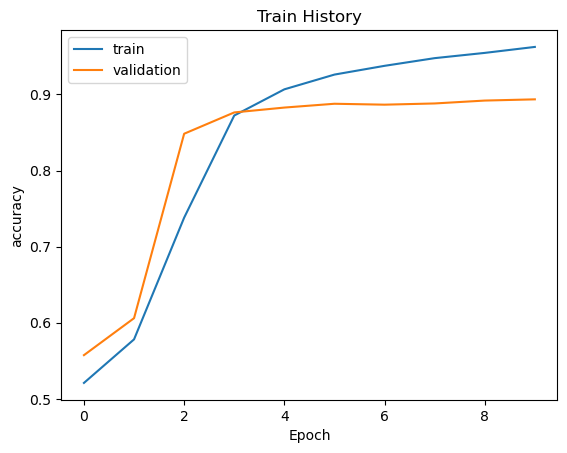

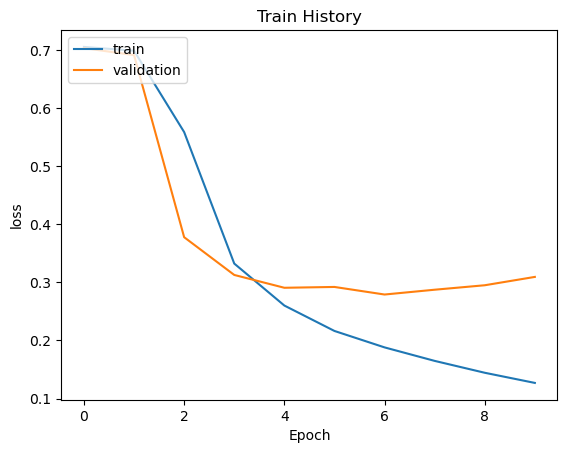

In [30]:
show_train_history(train_history, 'accuracy', 'val_accuracy')
show_train_history(train_history, 'loss', 'val_loss')

## 评估模型的准确率

In [31]:
loss, accu = model.evaluate(x_val_pad, y_val, verbose=1)
print('accuracy: %.4f' % accu)
print('loss: %.4f' % loss)

782/782 [==============================] - 96s 122ms/step - loss: 0.2958 - accuracy: 0.8806
accuracy: 0.8806
loss: 0.2958
